In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score
from base_utils import categoric_columns, numeric_columns


In [3]:
train_df = pd.read_csv('join.csv')

#### 빈도 레이블 인코딩

In [67]:
# for col in categorical_features:
#     freq_encoding = train_df[col].value_counts()
#     train_df[col] = train_df[col].map(freq_encoding) 

In [68]:
# correlation_matrix = train_df.corr()

In [69]:
# target_corr = correlation_matrix['임신 성공 여부'].drop('임신 성공 여부')
# print("\n목표 변수와의 상관계수:")
# print(target_corr)

In [71]:
# # 빈도 인코딩
# train_encoded = X.copy()

# for col in categoric_columns:
#     freq_encoding = X[col].value_counts().to_dict()
#     train_encoded[col] = X[col].map(freq_encoding)

In [4]:
X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

In [5]:
categorical_cols = X.select_dtypes(include=['object']).columns
encoder_dict = {}
for col in categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])
    #test_df[col] = encoder.transform(test_df[[col]])
    encoder_dict[col] = encoder

### 랜덤 포레스트 특성 중요도 추출

d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\

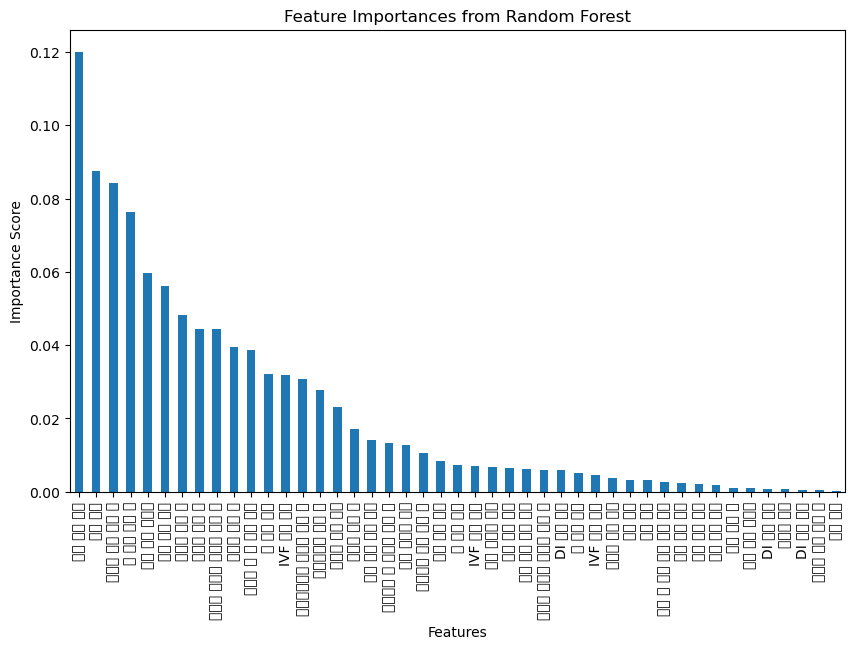

In [6]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# 특성 중요도 추출
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importances from Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

In [7]:
important_features = feature_importances[feature_importances > 0.01]
important_features

시술 시기 코드            0.120083
시술 당시 나이            0.056174
단일 배아 이식 여부         0.014123
불명확 불임 원인           0.023066
총 시술 횟수             0.032164
클리닉 내 총 시술 횟수       0.038776
IVF 시술 횟수           0.031884
총 생성 배아 수           0.076351
미세주입된 난자 수          0.027759
미세주입에서 생성된 배아 수     0.030806
이식된 배아 수            0.044348
미세주입 배아 이식 수        0.010606
저장된 배아 수            0.039457
미세주입 후 저장된 배아 수     0.013186
해동된 배아 수            0.017044
수집된 신선 난자 수         0.084201
혼합된 난자 수            0.048299
파트너 정자와 혼합된 난자 수    0.044324
정자 기증자 나이           0.012880
배아 이식 경과일           0.059604
불임 원인               0.087453
dtype: float64

In [8]:
# 중요도가 0.01 이상인 특성만 사용하여 데이터프레임 슬라이싱
train_df_cleaned = train_df[important_features.index]

train_df_cleaned['임신 성공 여부'] = y 
# # 새로운 CSV 파일로 저장
# train_df_cleaned.to_csv("train_df_important_features.csv", index=False, encoding='utf-8-sig')

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_7928\3082179976.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_cleaned['임신 성공 여부'] = y


In [9]:
X = train_df_cleaned.drop(["임신 성공 여부"], axis=1)
y = train_df_cleaned["임신 성공 여부"]

In [77]:
# # 빈도 인코딩
# train_encoded = X.copy()
# categorical_cols = train_df_cleaned.select_dtypes(include=['object']).columns
# for col in categorical_cols:
#     freq_encoding = X[col].value_counts().to_dict()
#     train_encoded[col] = X[col].map(freq_encoding)

In [10]:
categorical_cols = X.select_dtypes(include=['object']).columns
encoder_dict = {}
for col in categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])
    #test_df[col] = encoder.transform(test_df[[col]])
    encoder_dict[col] = encoder

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
y_val_proba = model.predict_proba(X_val)[:,1]
y_val_pred = (y_val_proba > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC PR:", average_precision_score(y_val, y_val_proba))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))

Accuracy: 0.7216360125607069
              precision    recall  f1-score   support

           0       0.77      0.89      0.83     38145
           1       0.42      0.22      0.29     13126

    accuracy                           0.72     51271
   macro avg       0.59      0.56      0.56     51271
weighted avg       0.68      0.72      0.69     51271

AUC PR: 0.3821509128117633
ROC AUC: 0.6956583185482743


In [15]:
xgmodel = XGBClassifier(use_label_encoder=False, eval_metric="auc", random_state=42)
xgmodel.fit(X_train, y_train)
y_val_proba = xgmodel.predict_proba(X_val)[:,1]
y_val_pred = (y_val_proba > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC PR:", average_precision_score(y_val, y_val_proba))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))

d:\env\envs\aimers\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:46:20] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.7456066782391605
              precision    recall  f1-score   support

           0       0.76      0.96      0.85     38145
           1       0.51      0.13      0.21     13126

    accuracy                           0.75     51271
   macro avg       0.64      0.54      0.53     51271
weighted avg       0.70      0.75      0.69     51271

AUC PR: 0.43509933420204067
ROC AUC: 0.732369187303785


In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, average_precision_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

# 데이터 불러오기
train_df = pd.read_csv('join.csv')
X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

# 범주형 변수 인코딩
categorical_cols = X.select_dtypes(include=['object']).columns
encoder_dict = {}
for col in categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])
    encoder_dict[col] = encoder

# 후진 제거 기법 적용
def backward_elimination(X, y, significance_level=0.05):
    X = sm.add_constant(X)  # 절편 추가
    while True:
        model = sm.OLS(y, X).fit()
        p_values = model.pvalues[1:]  # 절편 제외
        max_pval = p_values.max()  # 가장 높은 p-value 찾기
        
        if max_pval > significance_level:
            worst_feature = p_values.idxmax()
            X = X.drop(columns=[worst_feature])
        else:
            break
    
    return X.drop(columns=["const"])  # 절편 제거 후 반환

X_selected = backward_elimination(X, y)

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# XGBoost 모델 학습
xgmodel = XGBClassifier(use_label_encoder=False, eval_metric="auc", random_state=42)
xgmodel.fit(X_train, y_train)

# 예측 및 성능 평가
y_val_proba = xgmodel.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC PR:", average_precision_score(y_val, y_val_proba))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))


d:\env\envs\aimers\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:53:26] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.7456846950517837
              precision    recall  f1-score   support

           0       0.76      0.96      0.85     38145
           1       0.51      0.14      0.22     13126

    accuracy                           0.75     51271
   macro avg       0.64      0.55      0.53     51271
weighted avg       0.70      0.75      0.69     51271

AUC PR: 0.43909707917413393
ROC AUC: 0.7343069482717364


In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, average_precision_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from xgboost import XGBClassifier

# 데이터 불러오기
train_df = pd.read_csv('join.csv')
X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

# 범주형 변수 인코딩
categorical_cols = X.select_dtypes(include=['object']).columns
encoder_dict = {}
for col in categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])
    encoder_dict[col] = encoder

# 수치형 변수 스케일링
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost 모델 학습
xgmodel = XGBClassifier(use_label_encoder=False, eval_metric="auc", random_state=42)
xgmodel.fit(X_train, y_train)

# 예측 및 성능 평가
y_val_proba = xgmodel.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC PR:", average_precision_score(y_val, y_val_proba))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))


d:\env\envs\aimers\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:05:51] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.7467964346316631
              precision    recall  f1-score   support

           0       0.76      0.96      0.85     38145
           1       0.52      0.14      0.22     13126

    accuracy                           0.75     51271
   macro avg       0.64      0.55      0.53     51271
weighted avg       0.70      0.75      0.69     51271

AUC PR: 0.4409774441199911
ROC AUC: 0.7352720340021108


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, average_precision_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

# 데이터 불러오기
train_df = pd.read_csv('join_train.csv')
X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

# 범주형 변수 인코딩
categorical_cols = X.select_dtypes(include=['object']).columns
encoder_dict = {}
for col in categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])
    encoder_dict[col] = encoder

# 수치형 변수 스케일링
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# LinearSVC를 사용한 특성 선택
lsvc = LinearSVC(C=0.01, penalty="l1", dual=False, random_state=42, max_iter=2000)
lsvc.fit(X_train, y_train)

# SelectFromModel을 사용하여 중요 특성 선택
model = SelectFromModel(lsvc, prefit=True)
X_train_selected = model.transform(X_train)
X_val_selected = model.transform(X_val)

# 선택된 특성 확인
selected_features = X.columns[model.get_support()]
print("선택된 특성:", selected_features)

# XGBoost 모델 학습
xgmodel = XGBClassifier(use_label_encoder=False, eval_metric="auc", random_state=42)
xgmodel.fit(X_train_selected, y_train)

# 예측 및 성능 평가
y_val_proba = xgmodel.predict_proba(X_val_selected)[:, 1]
y_val_pred = (y_val_proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC PR:", average_precision_score(y_val, y_val_proba))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))


d:\env\envs\aimers\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
d:\env\envs\aimers\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


선택된 특성: Index(['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형',
       '단일 배아 이식 여부', '불명확 불임 원인', '배아 생성 주요 이유', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수',
       'DI 시술 횟수', '총 임신 횟수', '총 출산 횟수', '총 생성 배아 수', '미세주입에서 생성된 배아 수',
       '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '해동된 배아 수', '수집된 신선 난자 수',
       '혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '난자 기증자 나이',
       '정자 기증자 나이', '대리모 여부', '배아 이식 경과일', '불임 원인', '배아 사용 여부'],
      dtype='object')


d:\env\envs\aimers\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:02:39] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.7463868463653918
              precision    recall  f1-score   support

           0       0.76      0.95      0.85     38145
           1       0.52      0.14      0.22     13126

    accuracy                           0.75     51271
   macro avg       0.64      0.55      0.54     51271
weighted avg       0.70      0.75      0.69     51271

AUC PR: 0.44039386180668283
ROC AUC: 0.7356304115308422
